# Домашнее задание 1. Постановка и классификация задач, МНК, LP

**Выдано:** 9 сентября 2026. **Срок сдачи:** 23 сентября 2026 (до начала занятия). **Максимум:** 10 баллов (+1 бонус).

**Как сдавать.** Заполните этот ноутбук (ответы на теоретические вопросы — в markdown-ячейках, формулы в $\LaTeX$; код — в code-ячейках), выполните целиком (`Kernel → Restart Kernel and Run All Cells`) и сдайте через pull request: файл `submissions/hw01/<фамилия>.ipynb`, инструкция — [`CONTRIBUTING.md`](../CONTRIBUTING.md). Задачи можно обсуждать, но текст и код пишутся самостоятельно.

**Материал:** лекция 1 ([конспект](../lectures/lecture01/lecture01.md), [демо](../lectures/lecture01/demo01.ipynb)). Ничего сверх лекции не требуется.

Запуск: `uv sync` в корне репозитория, затем `uv run jupyter lab`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linprog, minimize

rng = np.random.default_rng(2026)   # не меняйте seed: данные должны совпадать у всех

## Задача 1. Классификация (4 балла)

Для каждой задачи (а)–(г) запишите её в стандартной форме

$$\min_x f(x) \quad\text{при}\quad g(x) = 0,\; h(x) \ge 0,$$

явно указав, что такое $x$ (и его размерность), $f$, $g$, $h$. Затем определите класс: LP / QP / QCQP / NLP; с ограничениями или без; выпуклая или нет (обоснуйте там, где это очевидно). По 1 баллу за пункт.

**(а)** Найти точку прямой $\{x \in \mathbb{R}^3 : x_1 + x_2 + x_3 = 1,\; x_1 - x_3 = 0\}$, ближайшую к точке $(1, 2, 3)$. *Дополнительно:* найдите эту точку (руками или численно).

**(б)** Диета: $n$ продуктов с ценами $c_j$; $m$ питательных веществ, продукт $j$ содержит $A_{ij}$ единиц вещества $i$. Купить продукты минимальной стоимости так, чтобы каждого вещества было не меньше $b_i$.

**(в)** Найти вписанный в единичный круг прямоугольник наибольшей площади (стороны параллельны осям).

**(г)** Подогнать модель $\varphi(t; x) = x_1 \sin(x_2 t + x_3)$ к измерениям $(t_i, y_i)$, $i = 1, \dots, N$, по критерию суммы квадратов невязок.

**(д, бонус +1)** $\min_{x \in \mathbb{R}^n} \max_i |a_i^\top x - b_i|$ (подгонка в чебышёвской норме). Переформулируйте как гладкую задачу с одной дополнительной переменной, по образцу переформулировки из раздела 8 лекции. Какой это класс?

**(а)**

**Ответ:**

$x\in\mathbb{R}^3$ — искомая точка прямой ($n=3$)

$f(x)=(x_1-1)^2+(x_2-2)^2+(x_3-3)^2$

$g:\mathbb{R}^3\to\mathbb{R}^2,\quad g(x)=\begin{pmatrix}x_1+x_2+x_3-1\\ x_1-x_3\end{pmatrix}$

$h:\mathbb{R}^3\to\mathbb{R}^0$ ($h$ отсутствует), т.к. неравенств нет

Минимизируем квадрат расстояния, а не само расстояние: $t\mapsto t^2$ монотонна на $t\ge0$, поэтому минимум тот же, но задача становится гладкой квадратичной.

Класс: QP с ограничениями (линейные равенства) и выпуклая

$\nabla^2 f=2I\succ0$, значит $f$ строго выпукла; $g$ аффинна, поэтому допустимое множество — аффинное подпространство (выпукло). Минимум единственный.

*Дополнительно.* Параметризуем прямую: из $x_1-x_3=0$ следует $x_1=x_3=t$, из $x_1+x_2+x_3=1$ — что $x_2=1-2t$. Тогда

$\varphi(t)=(t-1)^2+(2t+1)^2+(t-3)^2,\qquad \varphi'(t)=12t-4=0\;\Rightarrow\;t=\tfrac13$

$x^\*=\left(\tfrac13,\tfrac13,\tfrac13\right),\qquad \|x^\*-(1,2,3)^\top\|_2=\sqrt{\tfrac{31}{3}}\approx3.2146$

In [2]:
target: np.ndarray = np.array([1.0, 2.0, 3.0])
constraint_matrix: np.ndarray = np.array([[1.0, 1.0, 1.0], [1.0, 0.0, -1.0]])
constraint_rhs: np.ndarray = np.array([1.0, 0.0])

solution = minimize(
    lambda x: float(np.sum((x - target) ** 2)),
    np.zeros(3),
    constraints={"type": "eq", "fun": lambda x: constraint_matrix @ x - constraint_rhs},
)

print(f"x* = {np.round(solution.x, 3)}")
print(f"расстояние = {np.linalg.norm(solution.x - target):.3f}")

x* = [0.333 0.333 0.333]
расстояние = 3.215


**(б)**

**Ответ:**

$x\in\mathbb{R}^n$ — купленные количества продуктов ($x_j$ — количество продукта $j$)

$f(x)=c^\top x$

$g$ отсутствует ($g:\mathbb{R}^n\to\mathbb{R}^0$), равенств нет

$h:\mathbb{R}^n\to\mathbb{R}^{m+n},\quad h(x)=\begin{pmatrix}Ax-b\\ x\end{pmatrix}$

Первые $m$ компонент $h$ — требования «вещества $i$ не меньше $b_i$», последние $n$ — неотрицательность количеств (отрицательное количество продукта лишено смысла).

Класс: LP с ограничениями и выпуклая

Цель линейна, все ограничения аффинны, допустимое множество — полиэдр $\{x\ge0:Ax\ge b\}$, значит задача выпуклая (и одновременно вогнутая по цели, так что минимум достигается в вершине полиэдра, если он непуст и ограничен снизу).

**(в)**

**Ответ:** 

$X=(x,y)\in\mathbb{R}^2$

$x, y$ - координаты вершины прямоугольника в первом квадранте

$f(X) = -4xy$

$g: \mathbb{R}^2 \to \mathbb{R}, h: \mathbb{R}^2 \to \mathbb{R}^2$

$g(X) = (x^2+y^2-1)$

$h(X) = \begin{pmatrix} x \\ y \end{pmatrix}$

$g(X)$ таков, потому что бессмысленно искать прямоугольник не лежащий на окружности, так как для любого прямоугольника, не лежащего на окружности можно увеличить x (абсциссу) до лежания на окружности, что уменьшит f(X), если y > 0. (y=0 неоптимально, поэтому этот вариант не рассматривается)

Класс: QCQP с ограничениями и невыпуклая

$g(X)=0$ задаёт окружность — невыпуклое множество.

гессиан $\nabla^2 f = \begin{pmatrix}0 & -4 \\ -4 & 0\end{pmatrix}$ индефинитен (собственные значения $\pm4$);

**(г)**

**Ответ:**

$x=(x_1,x_2,x_3)\in\mathbb{R}^3$ — амплитуда, частота, фаза ($n=3$)

$f(x)=\sum_{i=1}^{N}\bigl(x_1\sin(x_2t_i+x_3)-y_i\bigr)^2$

$g$ и $h$ отсутствуют ($g:\mathbb{R}^3\to\mathbb{R}^0$, $h:\mathbb{R}^3\to\mathbb{R}^0$)

Класс: NLP без ограничений и невыпуклая

Невязки $r_i(x)=x_1\sin(x_2t_i+x_3)-y_i$ нелинейны по $x_2,x_3$, поэтому это нелинейный МНК, а не линейный. Невыпуклость видна сразу: $f(x_1,x_2,x_3+2\pi)=f(x_1,x_2,x_3)$, то есть $f$ периодична по $x_3$ и при этом не постоянна, а непостоянная периодическая функция выпуклой быть не может. Отсюда же множество локальных минимумов бесконечно (например, $(x_1,x_2,x_3)$ и $(-x_1,x_2,x_3+\pi)$ дают одно и то же значение).

**(д, бонус)**

**Ответ:** _(ваш текст; формулы — в $\LaTeX$)_

## Задача 2. Практика (6 баллов)

**(а) Линейный МНК и переобучение (3 балла).** Ниже сгенерированы обучающая и тестовая выборки: $y = \sin(2\pi t) + \varepsilon$, $\varepsilon \sim \mathcal{N}(0, 0.1^2)$. Для каждой степени $d = 1, \dots, 15$ подгоните полином $\varphi(t; x) = x_0 + x_1 t + \dots + x_d t^d$ методом наименьших квадратов (`numpy.linalg.lstsq`; матрицу $A$ удобно строить через `np.vander(t, d + 1, increasing=True)`). Постройте график зависимости среднеквадратичной ошибки на обучающей и на тестовой выборках от $d$ (ось $y$ — логарифмическая). Объясните поведение обеих кривых в двух-трёх предложениях: почему одна монотонна, а другая нет?

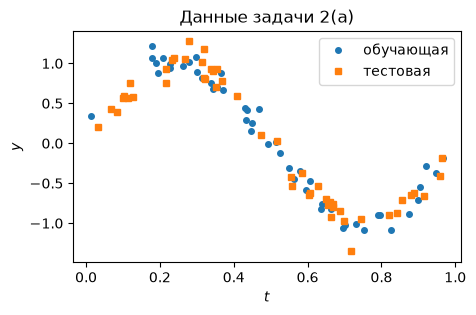

In [3]:
N = 50
t_train = np.sort(rng.uniform(0, 1, N))
y_train = np.sin(2 * np.pi * t_train) + 0.1 * rng.standard_normal(N)
t_test = np.sort(rng.uniform(0, 1, N))
y_test = np.sin(2 * np.pi * t_test) + 0.1 * rng.standard_normal(N)

plt.figure(figsize=(5, 3))
plt.plot(t_train, y_train, "o", ms=4, label="обучающая")
plt.plot(t_test, y_test, "s", ms=4, label="тестовая")
plt.legend(); plt.xlabel("$t$"); plt.ylabel("$y$"); plt.title("Данные задачи 2(а)")
plt.show()

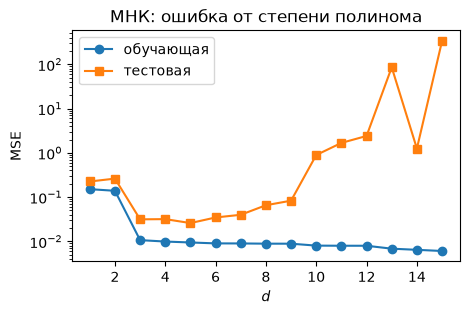

d =  1   train = 1.515e-01   test = 2.258e-01
d =  2   train = 1.391e-01   test = 2.621e-01
d =  3   train = 1.069e-02   test = 3.153e-02
d =  4   train = 9.933e-03   test = 3.188e-02
d =  5   train = 9.464e-03   test = 2.597e-02
d =  6   train = 9.030e-03   test = 3.474e-02
d =  7   train = 9.000e-03   test = 3.995e-02
d =  8   train = 8.896e-03   test = 6.567e-02
d =  9   train = 8.887e-03   test = 8.323e-02
d = 10   train = 8.038e-03   test = 8.942e-01
d = 11   train = 7.988e-03   test = 1.679e+00
d = 12   train = 7.981e-03   test = 2.410e+00
d = 13   train = 6.857e-03   test = 8.571e+01
d = 14   train = 6.461e-03   test = 1.250e+00
d = 15   train = 6.077e-03   test = 3.365e+02
минимум тестовой ошибки при d = 5: MSE = 2.597e-02


In [4]:
degrees: list[int] = list(range(1, 16))
mse_train: list[float] = []
mse_test: list[float] = []

for d in degrees:
    A_train = np.vander(t_train, d + 1, increasing=True)
    coeffs, *_ = np.linalg.lstsq(A_train, y_train, rcond=None)
    A_test = np.vander(t_test, d + 1, increasing=True)
    mse_train.append(float(np.mean((A_train @ coeffs - y_train) ** 2)))
    mse_test.append(float(np.mean((A_test @ coeffs - y_test) ** 2)))

plt.figure(figsize=(5, 3))
plt.semilogy(degrees, mse_train, "o-", label="обучающая")
plt.semilogy(degrees, mse_test, "s-", label="тестовая")
plt.legend(); plt.xlabel("$d$"); plt.ylabel("MSE"); plt.title("МНК: ошибка от степени полинома")
plt.show()

best_degree: int = degrees[int(np.argmin(mse_test))]

for d, train_error, test_error in zip(degrees, mse_train, mse_test):
    print(f"d = {d:2d}   train = {train_error:.3e}   test = {test_error:.3e}")

print(f"минимум тестовой ошибки при d = {best_degree}: MSE = {min(mse_test):.3e}")

**Ответ:**

Обучающая кривая монотонно не возрастает, потому что полиномы степени $\le d$ вложены в полиномы степени $\le d+1$, а МНК минимизирует ровно ту величину, которую мы рисуем: минимум по большему множеству не может быть больше, чем по меньшему. Тестовая ошибка нами не минимизируется, поэтому она не обязана падать: до $d\approx5$ модель наращивает полезные члены разложения $\sin(2\pi t)$ и обе кривые падают вместе, а дальше лишние степени свободы подгоняют уже не сигнал, а шум $\varepsilon$ конкретной обучающей выборки — это переобучение, и на новых точках такой полином промахивается.

Усиливает эффект обусловленность: столбцы $\{1,t,\dots,t^d\}$ на $[0,1]$ почти коллинеарны, число обусловленности матрицы Вандермонда растёт экспоненциально по $d$, коэффициенты становятся огромными и знакопеременными, а решение — неустойчивым. Поэтому тестовая кривая при $d\gtrsim10$ не просто растёт, а скачет на порядки (до $\sim10^2$ при $d=15$), тогда как обучающая продолжает медленно сползать вниз.

**(б) LP: диета (3 балла).** Решите задачу диеты из 1(б) с помощью `scipy.optimize.linprog` для данных ниже (4 продукта, 3 вещества). Выведите оптимальное $x$ и стоимость. Определите, какие из ограничений $Ax \ge b$ и $x \ge 0$ **активны** в решении (невязка равна нулю с точностью $10^{-9}$). Затем увеличьте требование по первому веществу на единицу ($b_1 \to b_1 + 1$), решите заново и сравните: как изменились решение и стоимость? Изменился ли набор активных ограничений?

Подсказка: `linprog` минимизирует $c^\top x$ при $A_{ub} x \le b_{ub}$, поэтому ограничение $Ax \ge b$ нужно переписать со знаком минус; `bounds=(0, None)` задаёт $x \ge 0$.

In [5]:
c = np.array([2.0, 3.0, 1.5, 4.0])                # цены продуктов
A = np.array([[1.0, 2.0, 0.0, 3.0],
              [2.0, 1.0, 1.0, 1.0],
              [0.0, 3.0, 2.0, 2.0]])                 # содержание вещества i в продукте j
b = np.array([10.0, 8.0, 12.0])                     # минимальные требования

In [6]:
def solve_diet(requirements: np.ndarray) -> tuple[np.ndarray, float]:
    result = linprog(c, A_ub=-A, b_ub=-requirements, bounds=(0, None))
    if not result.success:
        raise Exception(f'Unsuccessful result: {result.message}')

    return result.x, float(result.fun)


def report_diet(title: str, requirements: np.ndarray) -> None:
    x_opt, cost = solve_diet(requirements)
    nutrient_slack = A @ x_opt - requirements
    active_nutrients = [i + 1 for i, slack in enumerate(nutrient_slack) if abs(slack) < 1e-9]
    active_bounds = [j + 1 for j, value in enumerate(x_opt) if abs(value) < 1e-9]

    print(title)
    print(f"  b            = {requirements}")
    print(f"  x*           = {np.round(x_opt, 9)}")
    print(f"  стоимость    = {cost:.9f}")
    print(f"  невязки Ax-b = {np.round(nutrient_slack, 12)}")
    print(f"  активны Ax>=b по веществам: {active_nutrients}")
    print(f"  активны x>=0 по продуктам:  {active_bounds}")


report_diet("исходная задача", b)
print()
report_diet("требование по первому веществу увеличено на 1", b + np.array([1.0, 0.0, 0.0]))

исходная задача
  b            = [10.  8. 12.]
  x*           = [ 2.  4. -0.  0.]
  стоимость    = 16.000000000
  невязки Ax-b = [0. 0. 0.]
  активны Ax>=b по веществам: [1, 2, 3]
  активны x>=0 по продуктам:  [3, 4]

требование по первому веществу увеличено на 1
  b            = [11.  8. 12.]
  x*           = [1.88888889 3.55555556 0.         0.66666667]
  стоимость    = 17.111111111
  невязки Ax-b = [0. 0. 0.]
  активны Ax>=b по веществам: [1, 2, 3]
  активны x>=0 по продуктам:  [3]


**Ответ:**

Исходная задача: $x^\*=(2,\,4,\,0,\,0)$, стоимость $c^\top x^\*=16$. Невязки $Ax^\*-b=(0,0,0)$, то есть активны **все три** ограничения $Ax\ge b$ (все вещества добраны ровно до нормы, запаса нет) и два ограничения неотрицательности — $x_3=0$, $x_4=0$ (продукты 3 и 4 не покупаются). Всего 5 активных ограничений при $n=4$ переменных: решение — вершина полиэдра.

После $b_1\to b_1+1=11$: $x^\*=\left(\tfrac{17}{9},\,\tfrac{32}{9},\,0,\,\tfrac23\right)\approx(1.889,\,3.556,\,0,\,0.667)$, стоимость $\tfrac{154}{9}\approx17.111$. Она выросла на $\tfrac{10}{9}\approx1.111$ — это теневая цена (двойственная переменная) первого ограничения: ровно столько стоит одна дополнительная единица первого вещества в окрестности данного решения.

Набор активных ограничений изменился. Все три ограничения $Ax\ge b$ по-прежнему активны, но среди границ $x\ge0$ активным осталось только $x_3=0$: продукт 4 вошёл в решение ($x_4=\tfrac23>0$), и ограничение $x_4\ge0$ стало неактивным. Заодно уменьшились $x_1$ и $x_2$ — оптимум перескочил в соседнюю вершину полиэдра, сменив базис.